# Lab-02 - Morphological Image Processing


    Goal :  Identify ‘a’ in this picture

## Methodology
1. Image Binarization
2. Adaptive Kernel Generation
3. Morphological Identification (Hit-or-Miss)
4. Morphological Reconstruction (The "Grow" Step)
5. Coordinate Extraction and Highlighting

## Step-0 : Import nesesary library

In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Step-1 : Image Binarization

In [17]:
book = cv2.imread('source/case2_book.png')
book_gray = cv2.imread('source/case2_book.png', cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(book_gray, 127, 255, cv2.THRESH_BINARY)

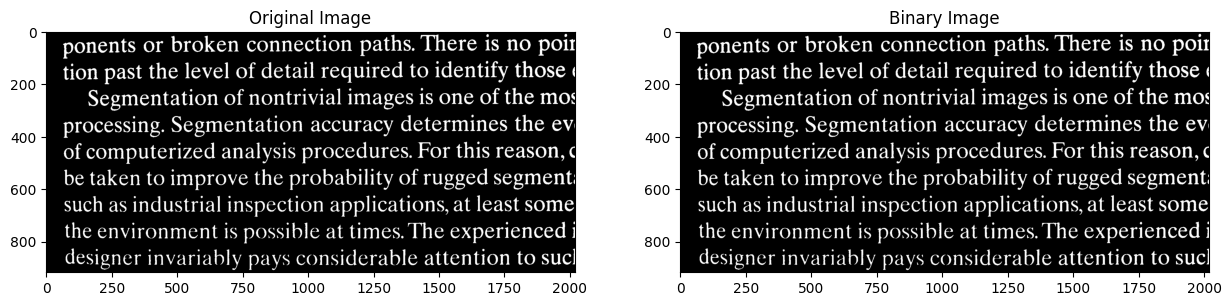

In [18]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(book, cmap='gray')
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.imshow(binary, cmap='gray')
plt.title('Binary Image')
plt.show()

## Step-2 : Adaptive Kernel Generation

In [19]:
x, y, w, h = 1246, 33, 39, 44
roi = binary[y:y+h, x:x+w]

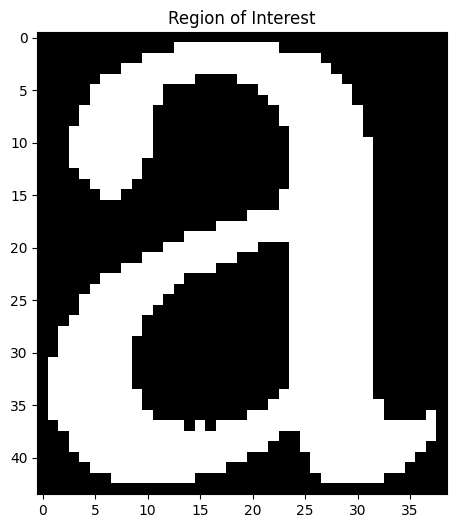

In [20]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(roi, cmap='gray')
plt.title('Region of Interest')
plt.show()

    To prevent kernel too overfit we erode kernel to small structure

In [21]:
se = np.ones((2, 2), np.uint8)

hit_part = cv2.erode(roi, se, iterations=4) 

miss_part = cv2.dilate(roi, se, iterations=2)
miss_part = cv2.bitwise_not(miss_part)

kernel = np.zeros(roi.shape, dtype=np.int8)
kernel[hit_part == 255] = 1   # Must be white
kernel[miss_part == 255] = 0  # Must be black


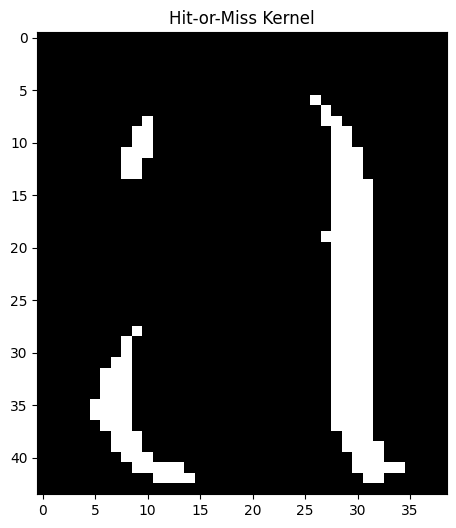

In [22]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(kernel, cmap='gray')
plt.title('Hit-or-Miss Kernel')
plt.show()

## Step-3 : Morphological Identification (Hit-or-Miss)

In [23]:
detected = cv2.morphologyEx(binary, cv2.MORPH_HITMISS, kernel)

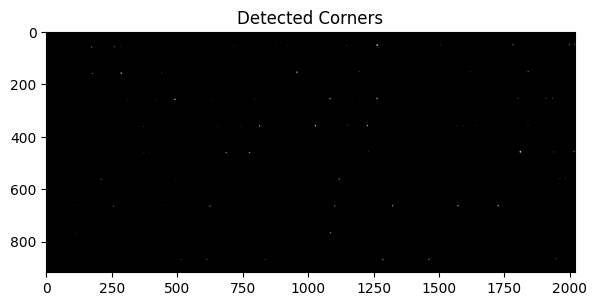

In [24]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(detected, cmap='gray')
plt.title('Detected Corners')
plt.show()

## Step-4 : Morphological Reconstruction (The "Grow" Step)

In [25]:
marker = detected.copy()
mask = binary.copy()

kernel_3x3 = np.ones((3, 3), np.uint8)

while True:
    expanded = cv2.dilate(marker, kernel_3x3)
    expanded = cv2.bitwise_and(expanded, mask)
    
    if np.array_equal(marker, expanded):
        break
    marker = expanded

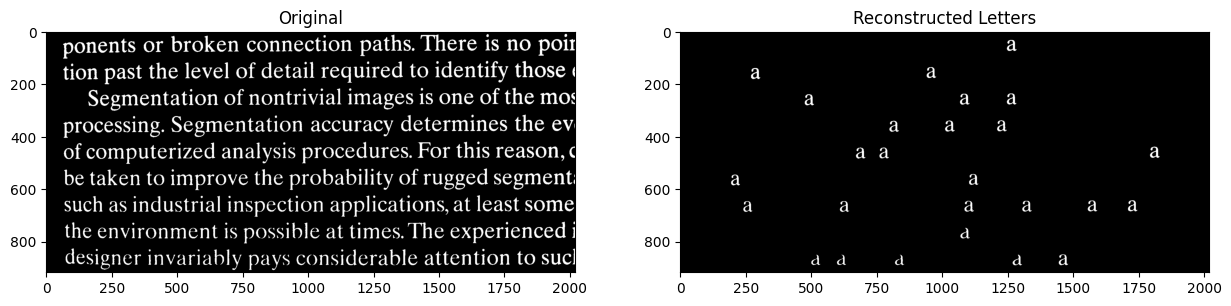

In [26]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(book, cmap='gray')
plt.title('Original')
plt.subplot(1, 2,2)
plt.imshow(marker, cmap='gray')
plt.title('Reconstructed Letters')
plt.show()

## Step-5 : Coordinate Extraction & Highlighting

In [27]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(marker)

for i in range(1, num_labels):
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    

    cv2.rectangle(book, (x - 7, y - 7), (x + w + 8, y + h + 8), (255, 0, 0), 5)

Text(0.5, 0, 'Number of Detected Letters: 26')

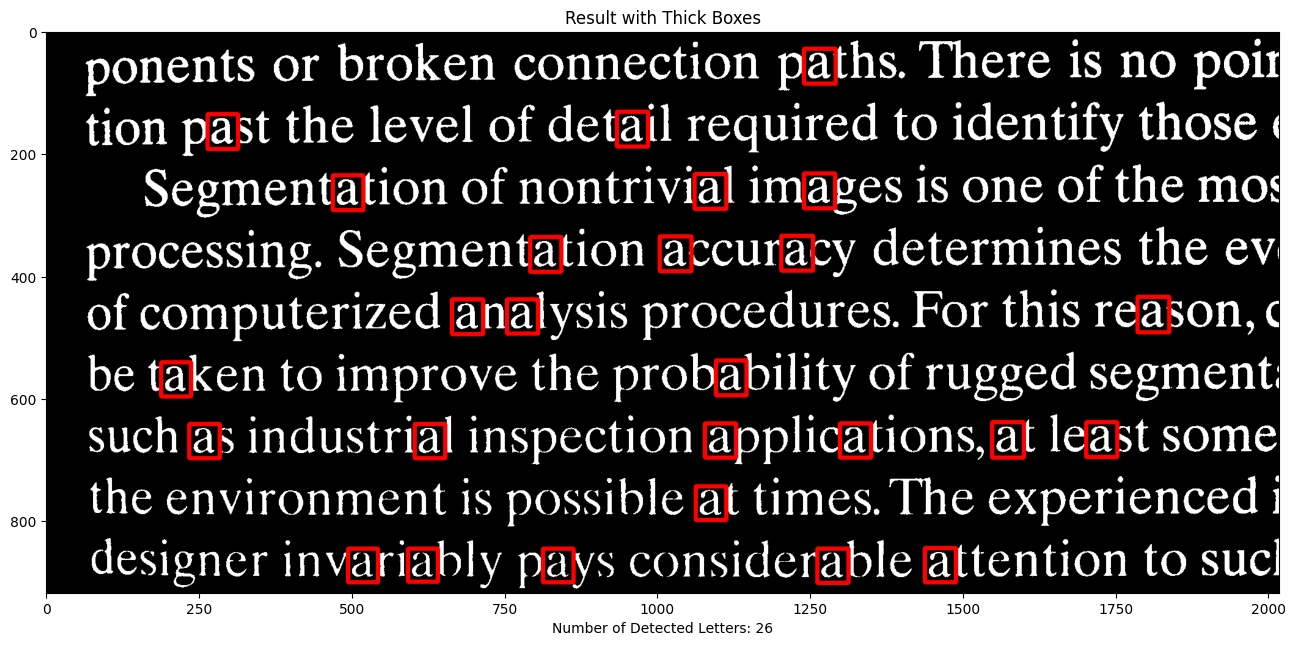

In [28]:
title = f'Number of Detected Letters: {num_labels - 1}'

plt.figure(figsize=(35, 10))
plt.subplot(1, 2, 1)
plt.imshow(book, cmap='gray')
plt.title('Result with Thick Boxes')
plt.xlabel(title)

## As we can see we indentify an "a" we get total : 26 characters